In [3]:
# Example of prompt chaining using LangGraph and LangChain

from langgraph.graph import StateGraph, START, END
from langchain_anthropic import ChatAnthropic
from typing import TypedDict
from dotenv import load_dotenv



In [4]:
load_dotenv()

model = ChatAnthropic(model='claude-sonnet-5')

In [7]:
class BlogState(TypedDict):

    title: str
    outline: str
    content: str

In [8]:
def create_outline(state: BlogState) -> BlogState:

    # fetch title
    title = state['title']

    # call llm gen outline
    prompt = f'Generate a detailed outline for a blog on the topic - {title}'
    outline = model.invoke(prompt).content

    # update state
    state['outline'] = outline
    return state

In [9]:
def create_blog(state: BlogState) -> BlogState:

    title = state['title']
    outline = state['outline']

    prompt = f'Write a detailed blog on the title - {title} using the follwing outline \n {outline}'

    content = model.invoke(prompt).content

    state['content'] = content

    return state

In [11]:
graph = StateGraph(BlogState)

# nodes
graph.add_node('create_outline', create_outline)
graph.add_node('create_blog', create_blog)

# edges
graph.add_edge(START, 'create_outline')
graph.add_edge('create_outline', 'create_blog')
graph.add_edge('create_blog', END)


In [ ]:
workflow =graph.compile()

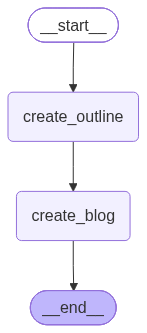

In [19]:
workflow

In [16]:
intial_state = {'title': 'Rise of AI in India'}

final_state = workflow.invoke(intial_state)

print(final_state['content'])

[{'signature': 'ErUICqQBCBIYAipAywrkKAtuUlj6hTsg8b3LsUAoMuc6fl0FVsZtFonNGxzL5V+G4yN5ZQPExuP/dyYY6iBMi9fXP4OHyywXWIXQdDIPY2xhdWRlLXNvbm5ldC01OABCCHRoaW5raW5nWiQ1NjkzNTYwMy05NGI3LTRkNjgtODMwMC1jOWJhN2YwZWYxMWOaAREKD2NsYXVkZS1zb25uZXQtNagB9IKN1gYSDJH6piTLvkmkG0dW2xoMwpe10O7dfGcIRryZIjDTxPGtPU2qgGs54mdHbPzjShmJzMOQuwo2yNGe0nv2eu/HRwtlDcpvSpICvIp8yRwqvQaphQLTbMAZ5FL+KwO02nbgLBuAqF/9Z4Zq45cQKDykvp9fBLm0Iq5Vag3rhK/zBLkEJgg2LFMvU4sfC+STiXBfnSddyCFPcmMYWvSjJRb8Vp0YpeJ+omUHmsd5Eo51ffmB9EFNGF8Yl/bwlirGcjWFzbQkJsBJXhA7vUrFXuQzo8k7oQyYAWJoPYWlBf414szIKxSdmbe5mvPr+AJYtkc2+m+hTI6FPfFx5SipaFbgaXnc0ueXvb7jPhyKvQ/7wv/NHfyyrSm5NEixO0dsKWzReFwBaDvllg5uopg1BSqPvKH13iWeNIQ0MHPZcRAmb3olUhDmzCBBBXytkVTDalTCRpU1DGehPuSx4W8KS9oo8b4wki/amQgGIr6d4feGWfHRtAboCjmSYSGTd0IdBPBOzS9KPo5nT2vrFVQ/i/ehPs23uGC69FrR9v/0hsYNhiwdNhSMhAFD+vPbk63OrNDxYCPxp0yv8OyQnGOFKQ2Xu3XWc3o7qzlKLW7TAK/QtKBY4Pvae0jGkpVV9TYumCCFKieNGxoxy7dwo5841y42VIoYf73SDPlvnD/NAK0UDZT/IhD8Fuok3T4HqoUHjzt2A3aU43UB6ikGX5eb+e8tdOln3BN14qw/u0a173hWfmzk4JnLFTza